# VR Chinese OCR Evaluation
### Deep Learning for Media — MPATE-GE 2039 / DM-GY 9103

**Goal:** Evaluate four OCR models on handwritten Chinese characters under nine VR-simulated perturbations to determine which model is best suited for a Meta Quest whiteboard application.

**Models evaluated:** ANCHOR · PaddleOCR · EasyOCR · CnOCR

**Dataset:** CASIA-HWDB (Kaggle) — offline handwritten Chinese characters

## 1. Setup

In [2]:
import sys
from pathlib import Path

# Add repo root to path so all modules are importable from the notebook
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

print(f'Repo root: {repo_root}')

Repo root: /Users/kayliestuteville/vr-chinese-ocr-eval


## 2. Load Data

Data is pre-generated and stored in `notebooks/data/`. Run `python regenerate_data.py` from the repo root if you need to rebuild these files.

**Test set composition:**
- ~818 clean samples (unperturbed baseline)
- ~88–107 samples per perturbation type (9 types)
- All labels are verified Chinese characters (CJK Unicode range)

In [3]:
data_dir = Path('data')

X_train    = np.load(data_dir / 'X_train.npy',    allow_pickle=True)
X_test     = np.load(data_dir / 'X_test.npy',     allow_pickle=True)
y_train    = np.load(data_dir / 'y_train.npy',    allow_pickle=True)
y_test     = np.load(data_dir / 'y_test.npy',     allow_pickle=True)
pert_types = np.load(data_dir / 'pert_types.npy', allow_pickle=True)

print(f'Train: {len(X_train):,} samples')
print(f'Test:  {len(X_test):,} samples')
print(f'\nTest set breakdown:')
counts = Counter(str(p) for p in pert_types)
for k, v in sorted(counts.items()):
    label = 'clean' if k == 'None' else k
    print(f'  {label:30s}: {v} samples')

Train: 6,838 samples
Test:  1,698 samples

Test set breakdown:
  clean                         : 818 samples
  contrast_variation            : 107 samples
  gaussian_noise                : 100 samples
  light_streak                  : 88 samples
  low_resolution                : 96 samples
  motion_blur                   : 103 samples
  occlusion                     : 98 samples
  perspective_warp              : 90 samples
  radial_glare                  : 98 samples
  white_balance_shift           : 100 samples


### Sample images

/var/folders/08/9lygww0n7gs7_gtsdmn588pc0000gn/T/ipykernel_84155/3159748469.py:12: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/08/9lygww0n7gs7_gtsdmn588pc0000gn/T/ipykernel_84155/3159748469.py:12: UserWarning: Glyph 34935 (\N{CJK UNIFIED IDEOGRAPH-8877}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/08/9lygww0n7gs7_gtsdmn588pc0000gn/T/ipykernel_84155/3159748469.py:12: UserWarning: Glyph 36315 (\N{CJK UNIFIED IDEOGRAPH-8DDB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/08/9lygww0n7gs7_gtsdmn588pc0000gn/T/ipykernel_84155/3159748469.py:12: UserWarning: Glyph 36991 (\N{CJK UNIFIED IDEOGRAPH-907F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/08/9lygww0n7gs7_gtsdmn588pc0000gn/T/ipykernel_84155/3159748469.py:12: UserWarning: Glyph 20329 (\N{CJK UNIFIED IDEOGRAPH-4F69}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/08/9lyg

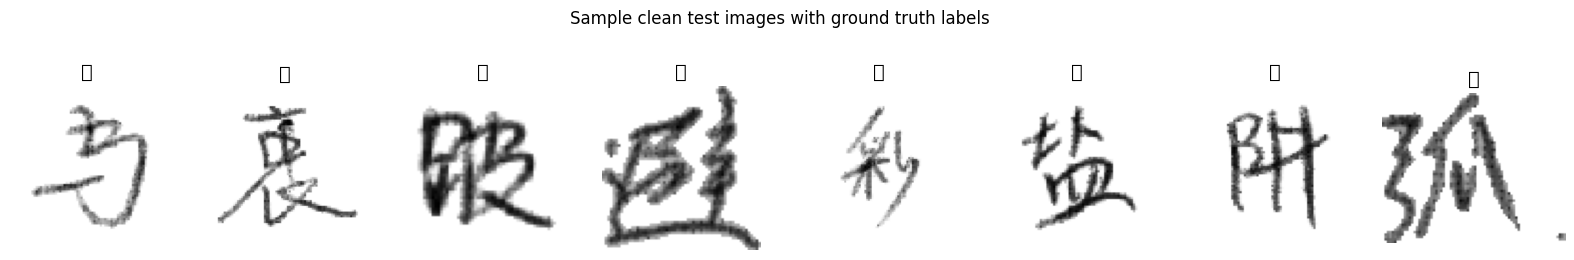

In [4]:
# Show a few clean test samples with their ground truth labels
clean_mask = np.array([p is None for p in pert_types])
X_clean = X_test[clean_mask]
y_clean = y_test[clean_mask]

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(X_clean[i], cmap='gray')
    ax.set_title(y_clean[i], fontsize=14)
    ax.axis('off')
plt.suptitle('Sample clean test images with ground truth labels', y=1.02)
plt.tight_layout()
plt.show()

## 3. Perturbation Visualization

Each perturbation simulates a real condition encountered when using a Meta Quest headset to view a physical whiteboard.

  Applying: radial_glare ...
  Applying: light_streak ...
  Applying: gaussian_noise ...
  Applying: contrast_variation ...
  Applying: occlusion ...
  Applying: perspective_warp ...
  Applying: motion_blur ...
  Applying: white_balance_shift ...
  Applying: low_resolution ...


/Users/kayliestuteville/vr-chinese-ocr-eval/perturbations/perturbation_analysis.py:226: UserWarning: Glyph 27796 (\N{CJK UNIFIED IDEOGRAPH-6C94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kayliestuteville/vr-chinese-ocr-eval/perturbations/perturbation_analysis.py:226: UserWarning: Glyph 31069 (\N{CJK UNIFIED IDEOGRAPH-795D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kayliestuteville/vr-chinese-ocr-eval/perturbations/perturbation_analysis.py:226: UserWarning: Glyph 38417 (\N{CJK UNIFIED IDEOGRAPH-9611}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kayliestuteville/vr-chinese-ocr-eval/perturbations/perturbation_analysis.py:226: UserWarning: Glyph 23547 (\N{CJK UNIFIED IDEOGRAPH-5BFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kayliestuteville/vr-chinese-ocr-eval/perturbations/perturbation_analysis.py:226: UserWarning: Glyph 36558 (\N{CJK UNIFIED IDEOGRAPH-8ECE}) missing from font(s) DejaVu Sans.
  plt.tight_layo

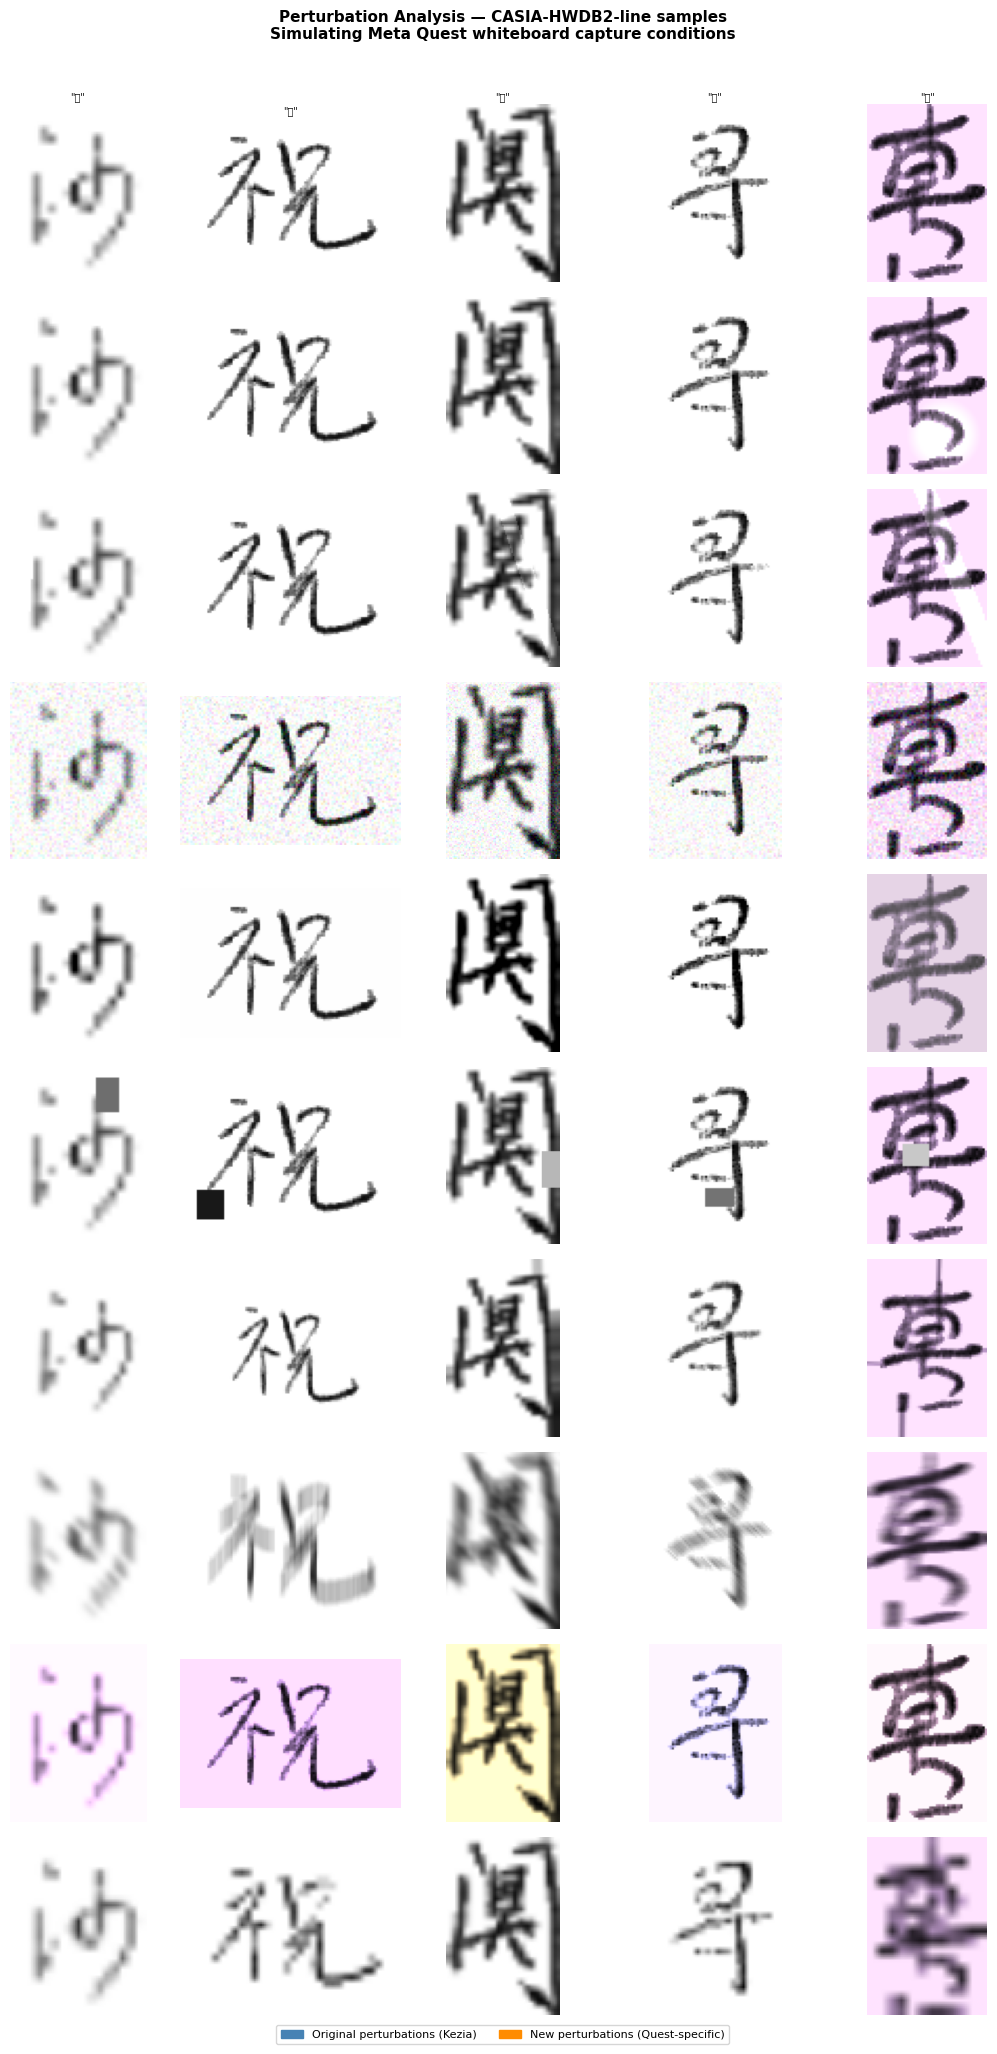


Done.


In [5]:
from perturbations.perturbation_analysis import show_perturbation_grid

show_perturbation_grid(
    images_raw=X_train,
    labels_raw=y_train,
    n_samples=5,
    save_path=None,
)

## 4. Model Inference

Each model is run on the full test set (clean + all 9 perturbation types). Predictions are cached to `../outputs/` so you only need to run inference once — subsequent notebook runs load from cache.

| Model | Architecture | Notes |
|---|---|---|
| **ANCHOR** | VGG-like CNN | Trained on CASIA-HWDB, 3755-class fixed vocabulary |
| **PaddleOCR** | Detection + recognition pipeline | Baidu production OCR, state of the art for Chinese |
| **EasyOCR** | CRAFT detector + CRNN | Open-source, Chinese support |
| **CnOCR** | DenseNet + GRU | Lightweight Chinese OCR library |

In [6]:
from models.anchor_inference     import run_anchor
from models.paddleocr_inference  import run_paddleocr
from models.easyocr_inference    import run_easyocr
from models.cnocr_inference      import run_cnocr

outputs_dir = Path('../outputs')
outputs_dir.mkdir(exist_ok=True)

model_fns = {
    'ANCHOR':    run_anchor,
    'PaddleOCR': run_paddleocr,
    'EasyOCR':   run_easyocr,
    'CnOCR':     run_cnocr,
}

predictions = {}
for name, fn in model_fns.items():
    cache_path = outputs_dir / f'preds_{name.lower()}_full.npy'
    if cache_path.exists():
        predictions[name] = np.load(cache_path, allow_pickle=True)
        print(f'{name}: loaded from cache')
    else:
        print(f'{name}: running inference...')
        predictions[name] = fn(X_test)
        np.save(cache_path, predictions[name])
        print(f'{name}: done, saved to {cache_path}')

/Users/kayliestuteville/.pyenv/versions/3.11.9/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


ANCHOR: loaded from cache
PaddleOCR: loaded from cache
EasyOCR: loaded from cache
CnOCR: loaded from cache


## 5. Evaluation

Metrics computed per model, overall and broken down by perturbation type:
- **Exact match accuracy** — top-1, predicted string equals ground truth
- **CER** — character error rate (lower is better)
- **Macro F1** — averaged across all character classes

In [7]:
from evaluation.metrics import evaluate
from evaluation.utils   import print_results_table, print_perturbation_table, print_robustness_table

results = {
    name: evaluate(preds, y_test, pert_types)
    for name, preds in predictions.items()
}

print('=== OVERALL RESULTS ===')
print_results_table(results)

=== OVERALL RESULTS ===
Model          Accuracy      CER   Precision   Recall       F1
──────────────────────────────────────────────────────────────
ANCHOR            54.3%    0.457       37.6%    39.5%    37.9%
PaddleOCR         38.3%    0.617       30.8%    30.3%    30.0%
EasyOCR           24.9%    0.751       21.0%    19.9%    20.1%
CnOCR             13.6%    0.864        8.5%     8.5%     8.2%


/Users/kayliestuteville/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/Users/kayliestuteville/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/Users/kayliestuteville/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
/Users/kayliestute

In [8]:
print('=== ACCURACY BY PERTURBATION TYPE ===')
print_perturbation_table(results)

=== ACCURACY BY PERTURBATION TYPE ===
Perturbation              ANCHOR PaddleOCR   EasyOCR     CnOCR
──────────────────────────────────────────────────────────────
clean                      58.1%     40.5%     26.9%     15.2%
contrast_variation         53.3%     46.7%     29.0%     14.0%
gaussian_noise             26.0%     41.0%     23.0%     18.0%
light_streak               63.6%     39.8%     22.7%     11.4%
low_resolution             47.9%     36.5%     12.5%      5.2%
motion_blur                27.2%      7.8%      1.9%      1.9%
occlusion                  58.2%     31.6%     24.5%     17.3%
perspective_warp           68.9%     42.2%     34.4%     11.1%
radial_glare               62.2%     44.9%     28.6%     19.4%
white_balance_shift        54.0%     37.0%     31.0%     11.0%


In [9]:
print('=== ROBUSTNESS GAP (accuracy drop from clean baseline) ===')
print_robustness_table(results)

=== ROBUSTNESS GAP (accuracy drop from clean baseline) ===

Robustness Gap (accuracy drop from clean — higher = more fragile)
Perturbation              ANCHOR PaddleOCR   EasyOCR     CnOCR
──────────────────────────────────────────────────────────────
contrast_variation          4.8%     -6.3%     -2.1%      1.1%
gaussian_noise             32.1%     -0.5%      3.9%     -2.8%
light_streak               -5.6%      0.7%      4.2%      3.8%
low_resolution             10.2%      4.0%     14.4%     10.0%
motion_blur                30.9%     32.7%     25.0%     13.2%
occlusion                  -0.1%      8.8%      2.4%     -2.2%
perspective_warp          -10.8%     -1.8%     -7.5%      4.0%
radial_glare               -4.2%     -4.4%     -1.7%     -4.2%
white_balance_shift         4.1%      3.5%     -4.1%      4.2%


## 6. Figures

Visualizations for the paper. All figures are also saved to `../outputs/`.

In [10]:
from evaluation.accuracy_curves import (
    plot_accuracy_by_perturbation,
    plot_robustness_gap_heatmap,
    plot_clean_comparison,
    plot_f1_by_perturbation,
)

plot_accuracy_by_perturbation(
    results,
    save_path=str(outputs_dir / 'fig_accuracy_by_perturbation.png')
)

Saved to ../outputs/fig_accuracy_by_perturbation.png


/Users/kayliestuteville/vr-chinese-ocr-eval/evaluation/accuracy_curves.py:102: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [11]:
plot_robustness_gap_heatmap(
    results,
    save_path=str(outputs_dir / 'fig_robustness_heatmap.png')
)

Saved to ../outputs/fig_robustness_heatmap.png


/Users/kayliestuteville/vr-chinese-ocr-eval/evaluation/accuracy_curves.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [12]:
plot_clean_comparison(
    results,
    save_path=str(outputs_dir / 'fig_clean_comparison.png')
)

Saved to ../outputs/fig_clean_comparison.png


/Users/kayliestuteville/vr-chinese-ocr-eval/evaluation/accuracy_curves.py:210: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [13]:
plot_f1_by_perturbation(
    results,
    save_path=str(outputs_dir / 'fig_f1_by_perturbation.png')
)

Saved to ../outputs/fig_f1_by_perturbation.png


/Users/kayliestuteville/vr-chinese-ocr-eval/evaluation/accuracy_curves.py:258: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Key Findings

**ANCHOR is the strongest model for VR handwriting recognition.** Despite being a 2013 model, it outperforms all three modern production OCR systems because it was purpose-built for isolated handwritten Chinese characters, the exact input type we have.

**VR-relevant perturbations (ranked by damage):**

| Perturbation | Most affected model | Least affected |
|---|---|---|
| Motion blur | PaddleOCR (−33pt) | CnOCR (−13pt) |
| Gaussian noise | ANCHOR (−32pt) | PaddleOCR (−0.5pt) |
| Low resolution | EasyOCR (−14pt) | PaddleOCR (−4pt) |
| Perspective warp | CnOCR (−4pt) | ANCHOR (improves) |

**Notable findings:**
- Motion blur is the single hardest perturbation, every model degrades significantly. This is the most important condition to address for a real VR deployment.
- Gaussian noise specifically destroys ANCHOR (−32 points) while barely affecting PaddleOCR (−0.5 points). ANCHOR relies on clean stroke patterns; noise corrupts them.
- ANCHOR is nearly unaffected by occlusion, suggesting its CNN learned to recognize partial strokes from the natural variation in real handwriting.
- TrOCR (no working Chinese handwriting checkpoint) and DINOv2 (<1% accuracy, insufficient per-class training data) were both ruled out, see the paper for details.
